# Exploratory Data Analysis

This is the first notebook in a from-scratch rewrite of a 2021 Elo7 Data Science take-home
challenge (full problem statement: [`../docs/elo7-ds-challenge-en.md`](../docs/elo7-ds-challenge-en.md)).
The question at the heart of the whole project is:

> Can a user's search intent be inferred from the search query alone?

Answering that eventually requires three systems: a product classifier, an unsupervised
search-intent model, and a hybrid recommender, built across the notebooks that follow this
one. Before any of that, we need to actually understand the data we're working with, which is
the job of this notebook.

## The data, briefly

The dataset (`../data/raw/elo7_recruitment_dataset.csv`) is 38,507 rows, each one a **click on
a product resulting from a search query**, not one row per product. A product can (and does)
appear more than once if it was clicked from more than one search. The columns fall into three
broad groups:

| Group | Columns |
|---|---|
| Search context | `query`, `search_page`, `position` |
| Product | `product_id`, `seller_id`, `title`, `concatenated_tags`, `creation_date`, `price`, `weight`, `express_delivery`, `minimum_quantity`, `view_counts`, `order_counts` |
| Target (Part 2) | `category` |

Full column-by-column semantics, dtypes, and known null counts are documented in
[`../data/README.md`](../data/README.md); this notebook builds on that rather than repeating
it, and links back to it where the detail matters.

## Questions this notebook answers

Numbered to match the section headers below, following the challenge's own suggestion to state
the questions before answering them:

1. **Data overview**: what's the actual unit of a row, and does that matter?
2. **Data quality**: where are the gaps, and what do we do about each one?
3. **Category distribution**: how imbalanced is the target for Part 2, and does it matter
   whether we count rows or distinct products?
4. **Product-level numeric features**: what do price, weight, and engagement look like, and
   how do they vary by category?
5. **Text features (tags & title)**: what's worth extracting from seller-provided text, and
   which of two competing feature designs should we keep?
6. **Search query deep dive**: what does query text look like on its own, and is there early
   evidence that category is recoverable from the query alone?
7. **Consolidated correlation**: which features move together, and what does that suggest for
   Part 2 (classification) and Part 3 (intent)?
8. **Key findings & handoff**: what do we carry into notebook 02?

## 1. Setup

We load the raw dataset through the project's own `src.data.load.load_raw_dataset`, which
already parses `creation_date` as a datetime, and pull in the text/numeric feature functions
from `src.features` that we'll use throughout this notebook (and reuse in later ones).

Two colors are defined once, up front, and reused everywhere a chart needs to tell two things
apart. We deliberately do *not* give every `category` its own color in charts where `category`
is already named on the x-axis: that would be a redundant rainbow encoding a single-series bar
chart doesn't need. Color is reserved for the cases where two genuinely different series share
one chart (e.g. `express_delivery` = yes/no, or two metrics side by side).

In [53]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data.load import load_raw_dataset
from src.features.numerical import days_since, order_probability, price_per_weight, rate_per_day
from src.features.text import char_length, tokenize, word_count

%matplotlib inline

PRIMARY = "#2a78d6"  # Blue, the default single hue for magnitude comparisons.
SECONDARY = "#eb6834"  # Orange, the second series whenever a chart compares exactly two things.

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 2. Data overview

In [54]:
df = load_raw_dataset()
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

38,507 rows x 15 columns


,product_id,seller_id,query,search_page,position,title,concatenated_tags,creation_date,price,weight,express_delivery,minimum_quantity,view_counts,order_counts,category
0,11394449,8324141,espirito santo,2,6,Mandala Espírito Santo,mandala mdf,2015-11-14 19:42:12,171.890000,1200.0,1,4,244,NaN,Decoração
1,15534262,6939286,cartao de visita,2,0,Cartão de Visita,cartao visita panfletos tag adesivos copos lon...,2018-04-04 20:55:07,77.670000,8.0,1,5,124,NaN,Papel e Cia
2,16153119,9835835,expositor de esmaltes,1,38,Organizador expositor p/ 70 esmaltes,expositor,2018-10-13 20:57:07,73.920006,2709.0,1,1,59,NaN,Outros
3,15877252,8071206,medidas lencol para berco americano,1,6,Jogo de Lençol Berço Estampado,t jogo lencol menino lencol berco,2017-02-27 13:26:03,118.770004,0.0,1,1,180,1.0,Bebê
4,15917108,7200773,adesivo box banheiro,3,38,ADESIVO BOX DE BANHEIRO,adesivo box banheiro,2017-05-09 13:18:38,191.810000,507.0,1,6,34,NaN,Decoração


The single most important thing to internalize before looking at any distribution is that a
row is a **click event**, not a product. Let's confirm the scale of that difference.

In [55]:
print(f"unique product_id : {df['product_id'].nunique():,}")
print(f"unique seller_id  : {df['seller_id'].nunique():,}")
print(f"rows              : {len(df):,}")

unique product_id : 29,801
unique seller_id  : 8,515
rows              : 38,507


29,801 distinct products and 8,515 distinct sellers, but 38,507 rows, so on average a product
in this sample was clicked ~1.3 times. That's mild, but it's not zero, and it means any chart
that counts *rows* per `category` is answering "which categories get clicked most," while a
chart that counts *distinct `product_id`* per `category` is answering "which categories have the
most catalog depth in this sample." Those are different questions, and we'll keep both readings
in view in §3.

It also matters for modeling later: a naive row-level train/test split for the Part 2 classifier
risks putting the same `product_id` (same title, same tags, same everything except the search
that led to the click) on both sides of the split. We'll flag this again in §8 as something the
classification notebook needs to handle explicitly, not something to solve here.

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38507 entries, 0 to 38506
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   product_id         38507 non-null  int64         
 1   seller_id          38507 non-null  int64         
 2   query              38507 non-null  object        
 3   search_page        38507 non-null  int64         
 4   position           38507 non-null  int64         
 5   title              38507 non-null  object        
 6   concatenated_tags  38505 non-null  object        
 7   creation_date      38507 non-null  datetime64[ns]
 8   price              38507 non-null  float64       
 9   weight             38449 non-null  float64       
 10  express_delivery   38507 non-null  int64         
 11  minimum_quantity   38507 non-null  int64         
 12  view_counts        38507 non-null  int64         
 13  order_counts       18117 non-null  float64       
 14  catego

## 3. Data quality

In [57]:
missing = df.isna().sum()
missing = missing[missing > 0]
pd.DataFrame({"n_missing": missing, "pct_missing": (100 * missing / len(df)).round(2)})

,n_missing,pct_missing
concatenated_tags,2,0.01
weight,58,0.15
order_counts,20390,52.95


Three columns have gaps, and each one gets a different treatment because each one means
something different:

**`order_counts`** is missing for 53% of rows, at first glance alarming, but look at what's
*not* missing:

In [58]:
non_null_orders = df["order_counts"].dropna()
print(f"non-null order_counts == 0 : {(non_null_orders == 0).sum()} of {len(non_null_orders):,}")
non_null_orders.describe()

non-null order_counts == 0 : 0 of 18,117


count    18117.00000
mean        27.38141
std         60.53336
min          1.00000
25%          8.00000
50%         15.00000
75%         26.00000
max       2460.00000
Name: order_counts, dtype: float64

Zero. Not one of the 18,117 non-null `order_counts` values is actually `0`. The minimum
recorded value is `1`. That's a strong signal that this column was only populated when a product
had at least one order in the window, and left blank otherwise, rather than being missing at
random. So a missing `order_counts` almost certainly means "zero orders," and we fill it with
`0` accordingly, not a guess, but the reading the data itself supports.

**`concatenated_tags`** is missing for only 2 rows. Both are products with a `title` and
`category` like any other; the seller simply left the tags field blank. We fill these with an
empty string `''`, which our tokenizer already treats as zero tokens, so nothing special is
needed downstream.

**`weight`** is missing for 58 rows (0.15%). This is small enough that dropping the rows
wouldn't meaningfully change any distribution, but dropping still throws away real click events
for no necessary reason, and other columns (`price`, `title`, `query`, `category`, ...) are
perfectly usable for those rows. So instead of dropping, we keep the rows and add an explicit
`weight_missing` flag, leaving `weight` itself as `NaN`. Anything computed *from* `weight` (like
`price_per_weight` in §4) will then propagate `NaN` for these rows automatically, rather than
silently blending "unknown" with some numeric stand-in.

In [59]:
df["order_counts"] = df["order_counts"].fillna(0)
df["concatenated_tags"] = df["concatenated_tags"].fillna("")
df["weight_missing"] = df["weight"].isna()

print(f"duplicated rows: {df.duplicated().sum()}")
print(f"weight == 0    : {(df['weight'] == 0).sum():,} ({100 * (df['weight'] == 0).mean():.1f}%)")
print(f"weight missing : {df['weight_missing'].sum()} ({100 * df['weight_missing'].mean():.2f}%)")

duplicated rows: 0
weight == 0    : 4,398 (11.4%)
weight missing : 58 (0.15%)


Worth calling out: `weight == 0` (11.4% of rows) and `weight` missing (0.15% of rows) are two
different things. A weight of exactly zero is a value the seller entered; a missing weight is a
value nobody entered. We'll treat these differently everywhere `weight` is used, starting with
`price_per_weight` below.

### The `order_probability` anomaly

`order_counts / view_counts` should be a legitimate estimate of the probability that a view
turns into an order, so it should never exceed 1. Let's check.

In [60]:
df["order_probability"] = order_probability(df["order_counts"], df["view_counts"])
anomaly = df[df["order_probability"] > 1]
print(f"rows with order_probability > 1 : {len(anomaly)} ({100 * len(anomaly) / len(df):.2f}%)")
anomaly["category"].value_counts()

rows with order_probability > 1 : 27 (0.07%)


category
Decoração             9
Bebê                  8
Lembrancinhas         8
Outros                1
Bijuterias e Jóias    1
Name: count, dtype: int64

27 rows (0.07%) have more recorded orders than views, presumably orders placed outside of a
search-driven view, or a quirk of how the three-month windows for each count were sampled. Before
dropping them, the question that matters is whether they're concentrated somewhere (a specific
category, a price range). If they were, dropping could quietly bias the remaining data.

In [61]:
share_of_category = (
    100 * anomaly["category"].value_counts() / df["category"].value_counts()
).round(2)
print("anomaly rows as a % of each category's own rows:")
print(share_of_category.sort_values(ascending=False))
print()
print("anomaly price stats vs. overall price stats:")
print(pd.concat([anomaly["price"].describe(), df["price"].describe()], axis=1, keys=["anomaly", "overall"]))

anomaly rows as a % of each category's own rows:
category
Bebê                  0.11
Bijuterias e Jóias    0.11
Decoração             0.10
Outros                0.09
Lembrancinhas         0.05
Papel e Cia            NaN
Name: count, dtype: float64

anomaly price stats vs. overall price stats:
           anomaly       overall
count    27.000000  38507.000000
mean    102.070000     84.054157
std     208.812541    211.805310
min       3.090000      0.070000
25%      25.945000     12.750000
50%      38.250000     28.490000
75%      83.570000     90.000000
max    1100.000000  11509.380000


No concentration: the anomaly touches 0.05–0.11% of rows in every category it appears in at all
(and doesn't appear in `Papel e Cia`), and the price distribution of the anomalous rows looks
like a smaller, noisier version of the overall price distribution, not a distinct population.
With no evidence of a systematic pattern and a volume this small, we drop these 27 rows rather
than flag them. Unlike `weight`, there's no case here for keeping and flagging, since the
anomaly makes `order_probability` itself indefensible for these specific rows without recomputing
it.

In [62]:
df = df[df["order_probability"] <= 1].reset_index(drop=True)
print(f"{len(df):,} rows remain")

38,480 rows remain


## 4. Category distribution

`category` is the target for Part 2's classifier, so its distribution matters twice: once for
understanding the catalog, and once for anticipating that a classifier trained on it will need
to handle real class imbalance. As flagged in §2, we look at this both per row (click volume)
and per distinct product (catalog depth).

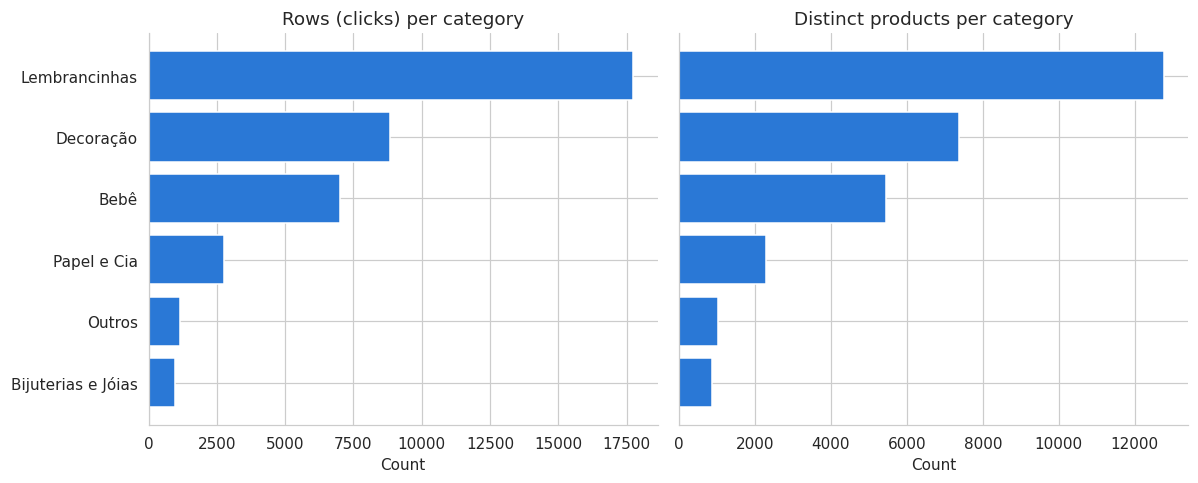

In [63]:
row_level = df["category"].value_counts()
product_level = df.drop_duplicates("product_id")["category"].value_counts().reindex(row_level.index)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

axs[0].barh(row_level.index[::-1], row_level.values[::-1], color=PRIMARY)
axs[0].set_title("Rows (clicks) per category")
axs[0].set_xlabel("Count")

axs[1].barh(product_level.index[::-1], product_level.values[::-1], color=PRIMARY)
axs[1].set_title("Distinct products per category")
axs[1].set_xlabel("Count")

fig.tight_layout()
plt.show()

Both readings tell the same story at different magnitudes: `Lembrancinhas` dominates (46% of
rows, 43% of distinct products), `Bijuterias e Jóias` is by far the smallest (2.5% of rows, 2.9%
of products), and the ranking of all six categories is identical either way. So for this
dataset, the row-vs-product distinction changes the exact percentages but not the qualitative
picture: the imbalance itself is real and roughly 18:1 between the largest and smallest class,
something Part 2's evaluation will need to account for (accuracy alone would reward a classifier
for just guessing `Lembrancinhas`).

It's also worth checking whether that same imbalance shows up in *engagement* (views and
orders), or whether some categories convert disproportionately well despite a smaller catalog.

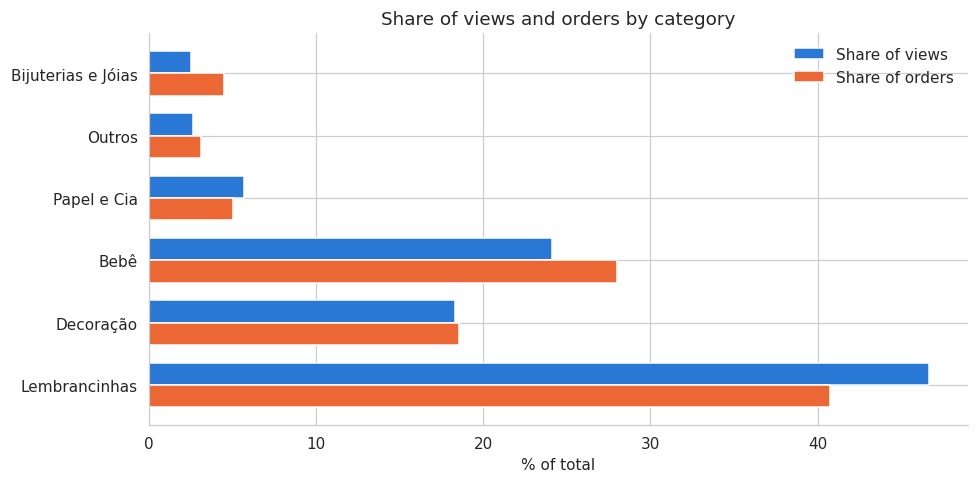

In [64]:
views_share = (100 * df.groupby("category")["view_counts"].sum() / df["view_counts"].sum()).reindex(row_level.index)
orders_share = (100 * df.groupby("category")["order_counts"].sum() / df["order_counts"].sum()).reindex(row_level.index)

fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(row_level))
height = 0.36

ax.barh(y + height / 2, views_share.values, height=height, color=PRIMARY, label="Share of views")
ax.barh(y - height / 2, orders_share.values, height=height, color=SECONDARY, label="Share of orders")
ax.set_yticks(y)
ax.set_yticklabels(row_level.index)
ax.set_xlabel("% of total")
ax.set_title("Share of views and orders by category")
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

`Bebê` is the interesting case: it's the third-largest category by product count (18%), but
pulls a disproportionate 24% of views and 28% of orders: it converts better than its catalog
size alone would predict. `Lembrancinhas` shows the opposite pattern for orders specifically
(41% of orders vs. 47% of views), high traffic, slightly lower conversion. Neither of these is
something to correct for in an EDA notebook, but they're useful context: a recommender that
leans purely on popularity (view/order counts) will already skew toward `Bebê` and
`Lembrancinhas` regardless of what the query says, which is exactly the kind of thing a
query-aware system is supposed to do better than.

## 5. Product-level numeric features

Now the rest of the numeric columns: `price`, `weight`, `minimum_quantity`, `express_delivery`,
`view_counts`, `order_counts`, plus `price_per_weight`, which we derive here.

In [65]:
df["price_per_weight"] = price_per_weight(df["price"], df["weight"])

print(f"price_per_weight nulls: {df['price_per_weight'].isna().sum()} (should equal weight nulls: {df['weight'].isna().sum()})")
df[["price", "weight", "price_per_weight", "minimum_quantity", "view_counts", "order_counts"]].describe()

price_per_weight nulls: 58 (should equal weight nulls: 58)


,price,weight,price_per_weight,minimum_quantity,view_counts,order_counts
count,38480.000000,38422.000000,38422.000000,38480.000000,38480.000000,38480.000000
mean,84.041516,361.075191,14.366134,14.602391,545.838773,12.820166
std,211.809533,1812.845573,81.253071,43.783599,1416.942852,43.258841
min,0.070000,0.000000,0.000034,0.000000,1.000000,0.000000
25%,12.750000,6.000000,0.228834,3.000000,119.000000,0.000000
50%,28.470000,9.000000,1.327889,7.000000,243.000000,0.000000
75%,90.000000,107.000000,7.272601,16.000000,521.000000,14.000000
max,11509.380000,65009.000000,5563.860000,3000.000000,45010.000000,2460.000000


The null count check confirms the design decision from §3 worked as intended: `price_per_weight`
is `NaN` for exactly the rows where `weight` was missing, and nowhere else: no silent blending
of "unknown" with a numeric placeholder.

The `describe()` table shows the pattern the challenge spec itself warns about ("[prices] may
not always reflect realistic market values"): `price` ranges from R$0.07 to R$11,509, with a
mean of 84 sitting well above the median of 28, heavily right-skewed (skewness ≈ 17.5). `weight`
and `view_counts` show the same shape (skewness ≈ 16.8 and ≈ 14.8 respectively). All three need a
log scale to plot sensibly, and any model using them raw should expect a few extreme outliers to
dominate unless that's addressed.

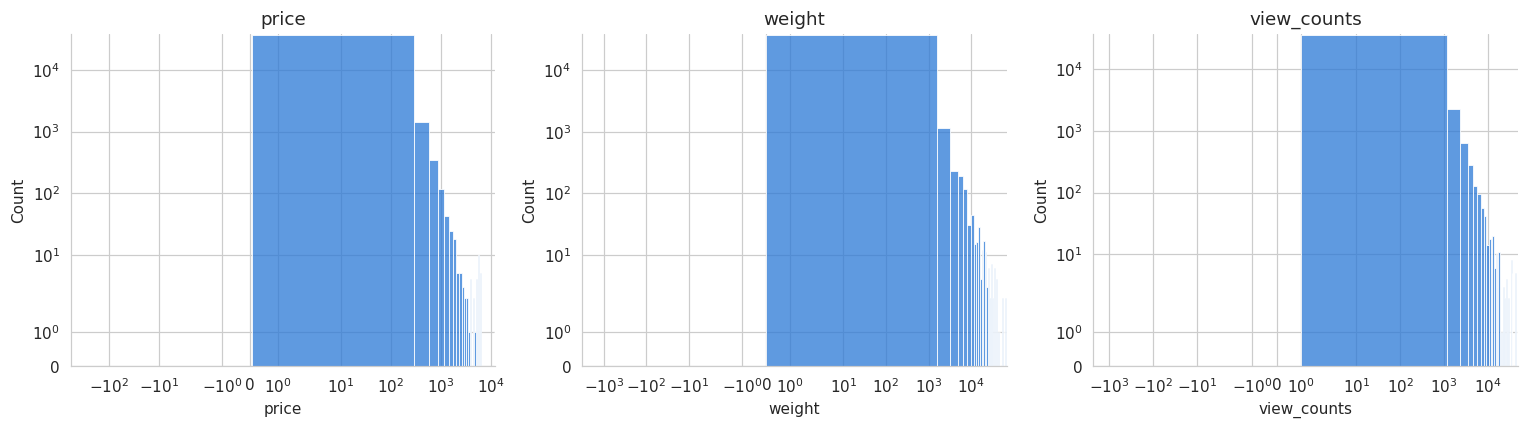

In [66]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axs, ["price", "weight", "view_counts"]):
    sns.histplot(df[col], ax=ax, color=PRIMARY, bins=40)
    ax.set_xscale("symlog")
    ax.set_yscale("symlog")
    ax.set_title(col)

fig.tight_layout()
plt.show()

Even in log-log scale, all three keep a long right tail: a handful of products with very high
price, weight, or view counts. This is expected for a marketplace catalog (a few products go
viral or are simply expensive/heavy specialty items) and isn't itself a data quality issue, but
it does mean summary statistics like the mean are not very representative; the median and the
shape of the distribution matter more here than any single number.

`express_delivery` is the one binary flag among these columns, so a two-color bar makes sense
here (this is exactly the "compare two things" case the color choice in §1 was reserved for):

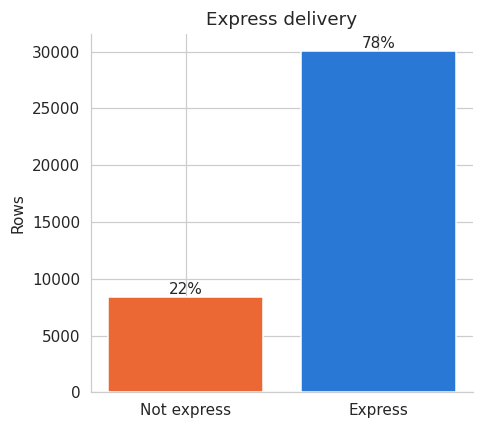

In [67]:
express_counts = df["express_delivery"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.bar(["Not express", "Express"], express_counts.values, color=[SECONDARY, PRIMARY])
ax.set_ylabel("Rows")
ax.set_title("Express delivery")
for i, v in enumerate(express_counts.values):
    ax.text(i, v, f"{100 * v / len(df):.0f}%", ha="center", va="bottom")
fig.tight_layout()
plt.show()

78% of clicked products offer express delivery: the large majority. Whether that reflects the
overall catalog or just what tends to get clicked isn't something this single chart can answer,
but it's a useful base rate to keep in mind: a classifier or recommender that ignores
`express_delivery` entirely isn't ignoring a 50/50 signal, it's ignoring something already
skewed 4-to-1.

Finally, how do price, weight, and engagement vary *by category*? Boxplots on a log scale, one
color throughout (the category is already the label on the x-axis, so a per-category rainbow
would be redundant here, same reasoning as §4's bar charts).

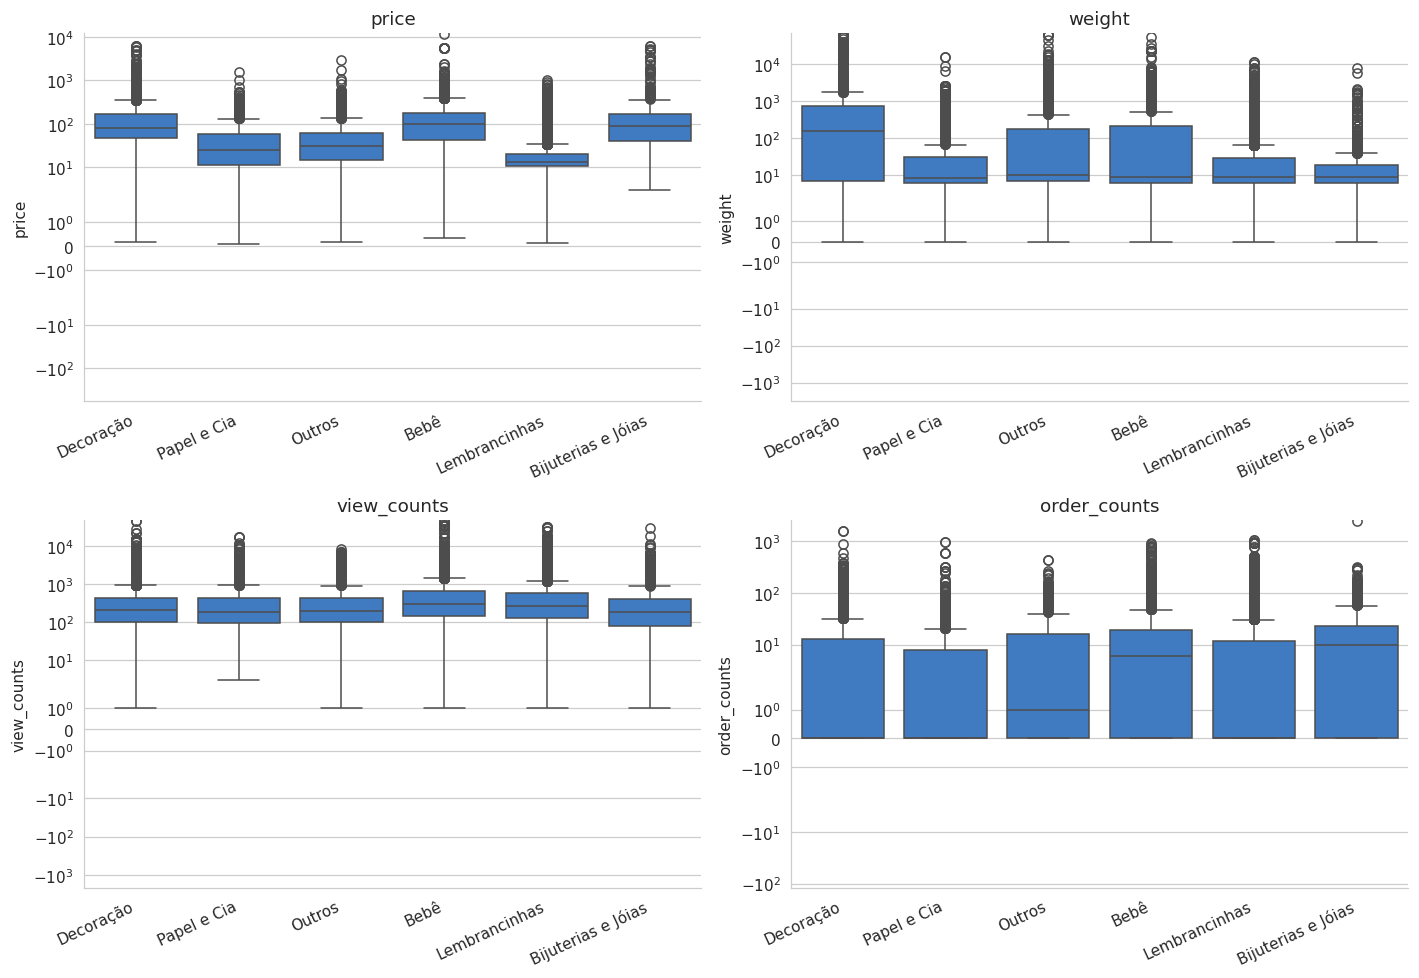

In [68]:
fig, axs = plt.subplots(2, 2, figsize=(13, 9))

for ax, col in zip(
    axs.flat, ["price", "weight", "view_counts", "order_counts"]
):
    sns.boxplot(data=df, x="category", y=col, ax=ax, color=PRIMARY)
    ax.set_yscale("symlog")
    for label in ax.get_xticklabels():
        label.set_rotation(25)
        label.set_ha("right")
    ax.set_title(col)
    ax.set_xlabel("")

fig.tight_layout()
plt.show()

`Decoração` stands out with a visibly higher weight distribution than the rest, consistent with
home-decor items (furniture pieces, large wall art) tending to be heavier than, say, party
favors or paper crafts. `price` varies less dramatically across categories than weight does, and
`view_counts`/`order_counts` echo the engagement pattern already seen in §4 (`Bebê` pulling
ahead of its catalog share). None of these differences look large enough on their own to make
`category` trivially separable from numeric features alone, which is exactly why Part 2 will
need `title`/`concatenated_tags` text as well, not just these numeric columns.

## 6. Text features: tags & title

Seller-provided tags and titles are unstructured text, but we can still extract useful signal
from them: how much information a seller provided, and what vocabulary shows up most often.

### Choosing a length feature: characters or words?

There are two natural ways to measure "how much text is here": count words, or count
characters. They're strongly related but not identical, so it's worth deciding deliberately
which one to keep rather than carrying both forward.

In [69]:
text_cols = ["concatenated_tags", "title", "query"]

for col in text_cols:
    df[f"n_words_{col}"] = df[col].map(word_count)
    df[f"n_chars_{col}"] = df[col].map(char_length)

feature_cols = [f"{prefix}_{col}" for col in text_cols for prefix in ("n_words", "n_chars")]
df[feature_cols].corr(numeric_only=True).loc[
    [f"n_words_{c}" for c in text_cols], [f"n_chars_{c}" for c in text_cols]
]

,n_chars_concatenated_tags,n_chars_title,n_chars_query
n_words_concatenated_tags,0.980424,0.083196,-0.009894
n_words_title,0.007967,0.854144,0.215439
n_words_query,-0.072988,0.216527,0.854662


Each field's own word-count and character-count are highly correlated with each other (as
expected: more words usually means more characters), and there's little cross-field
correlation, so this is really three separate choices (one per field), not one. To choose
between the word-count and character-count variant *within* each field, we look at how many
distinct values each one actually takes: a coarser feature (fewer distinct values) throws away
more information than a finer one at the same nominal "size."

In [70]:
for col in text_cols:
    n_word_vals = df[f"n_words_{col}"].nunique()
    n_char_vals = df[f"n_chars_{col}"].nunique()
    print(f"{col:20s} distinct word-counts: {n_word_vals:>4}   distinct char-counts: {n_char_vals:>4}")

concatenated_tags    distinct word-counts:   67   distinct char-counts:  328
title                distinct word-counts:   13   distinct char-counts:   58
query                distinct word-counts:   13   distinct char-counts:   70


For every field, the character-count variant has far more distinct values than the word-count
variant (e.g. `title`: 58 distinct character-lengths vs. only 13 distinct word-counts): the
word-count feature is heavily discretized (most titles are somewhere between 3 and 8 words, full
stop), while the character-count captures much finer variation. We keep the `len_*`
(character-count) variant for each field and drop the `n_words_*` variant.

In [71]:
df["len_tags"] = df["n_chars_concatenated_tags"]
df["len_title"] = df["n_chars_title"]
df["len_query"] = df["n_chars_query"]
df = df.drop(columns=[c for c in df.columns if c.startswith("n_words_") or c.startswith("n_chars_")])

### Most frequent tags and title words

Tags aren't full sentences, so we tokenize them without removing Portuguese stopwords (there's
essentially nothing but content words in a tag list anyway). Titles *are* closer to natural
language, so stopwords are dropped there to keep the frequency table meaningful.

227,244 tag tokens, 7,598 distinct
147,894 title tokens, 7,225 distinct


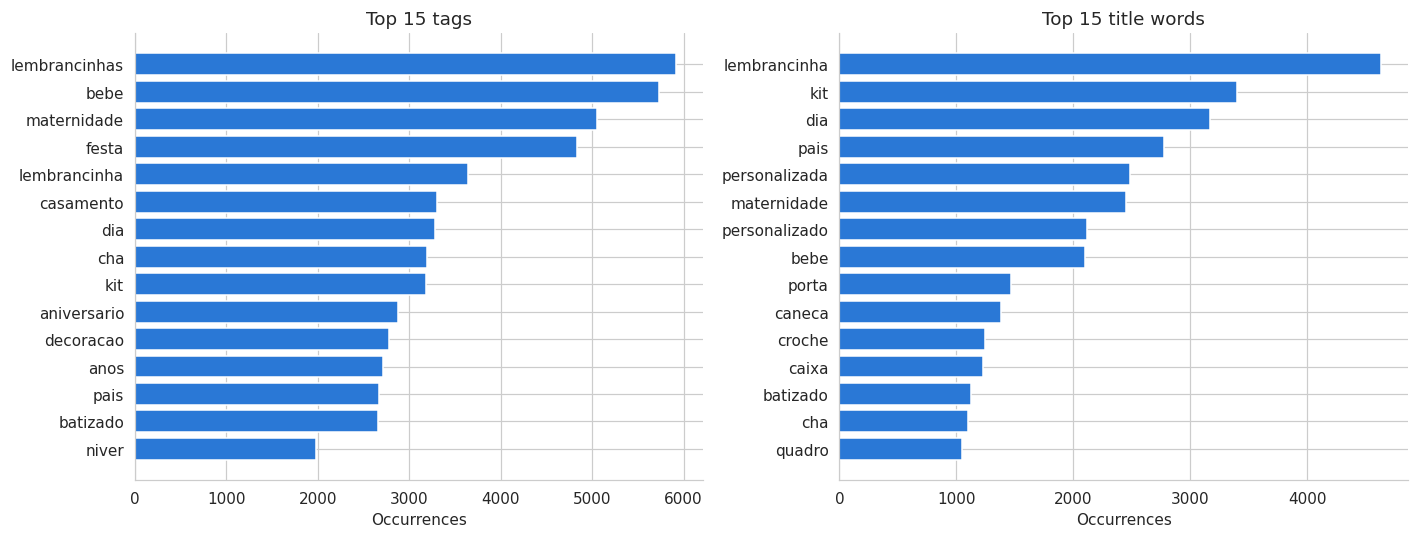

In [72]:
all_tags = [tag for tags in df["concatenated_tags"] for tag in tokenize(tags)]
tag_counts = Counter(all_tags)
print(f"{len(all_tags):,} tag tokens, {len(set(all_tags)):,} distinct")

all_title_words = [w for title in df["title"] for w in tokenize(title, drop_stopwords=True)]
title_counts = Counter(all_title_words)
print(f"{len(all_title_words):,} title tokens, {len(set(all_title_words)):,} distinct")

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
for ax, counts, label in zip(axs, [tag_counts, title_counts], ["tags", "title words"]):
    top = counts.most_common(15)
    words, freqs = zip(*top)
    ax.barh(words[::-1], freqs[::-1], color=PRIMARY)
    ax.set_title(f"Top 15 {label}")
    ax.set_xlabel("Occurrences")
fig.tight_layout()
plt.show()

Tags and titles surface a near-identical vocabulary: `lembrancinha(s)`, `bebe`, `maternidade`,
`kit`, `dia`, `pais`, `festa`, `croche`, `decoracao`, which isn't surprising (sellers write both
to be found for the same things) but is a useful sanity check that these two text fields aren't
capturing meaningfully different information about a product. It also previews the vocabulary
we'll compare against `query` in §7: if the same words dominate tags, titles, *and* queries, that
would be direct evidence that a query alone carries enough signal to recover a product's likely
category, which is the central question this whole project is built around.

## 7. Search query deep dive

This is the section that matters most for the project's actual thesis, and it's also the part
the original 2021 version of this analysis gave the least attention: `query` was treated with
the same shallow word-frequency pass as `title`/`concatenated_tags` and never compared against
`category`. Since notebooks 03 (intent modeling) and 05 (system integration) both depend on
understanding query text well, we go deeper here.

### Length and repetition

We already picked `len_query` (characters) as the length feature in §6. How much of the traffic
is repeat queries, versus one-off searches?

In [73]:
n_unique_queries = df["query"].nunique()
print(f"{n_unique_queries:,} distinct queries across {len(df):,} rows ({100 * n_unique_queries / len(df):.1f}% unique)")

query_counts = df["query"].value_counts()
top20_share = 100 * query_counts.head(20).sum() / len(df)
top100_share = 100 * query_counts.head(100).sum() / len(df)
singletons = (query_counts == 1).sum()

print(f"top 20 queries account for  {top20_share:.1f}% of all rows")
print(f"top 100 queries account for {top100_share:.1f}% of all rows")
print(f"{singletons:,} queries ({100 * singletons / n_unique_queries:.1f}% of distinct queries) appear exactly once")

query_counts.head(10)

6,392 distinct queries across 38,480 rows (16.6% unique)
top 20 queries account for  5.5% of all rows
top 100 queries account for 15.9% of all rows
1,427 queries (22.3% of distinct queries) appear exactly once


query
bolsa maternidade            152
dia dos pais                 148
lembrancinha dia dos pais    127
porta maternidade            126
batizado                     125
lembrancinha                 122
lembrancinha maternidade     122
lembrancinha batizado        121
lembrancinhas maternidade    117
presente dia dos pais        106
Name: count, dtype: int64

Search traffic is concentrated but not extremely so: the top 20 queries alone account for only
5.5% of all rows, and the top 100 for 16%. At the other end, 22% of distinct queries appear only
once in the whole sample. This is a long tail with a short, dense head, relevant for notebook
03's clustering, since it means a query-level intent model will need to generalize well beyond
the most common queries rather than just memorizing them, but it also means the head alone
(a few hundred queries) already covers a meaningful share of real traffic and is worth spot
checking by hand later.

### Does the query hint at the category?

This is the sharpest test EDA can run on this project's core question before any model exists:
if we group rows by `category` and look at the most common query words *within* each group, do
we see visibly different vocabularies, or is it the same handful of generic words everywhere?

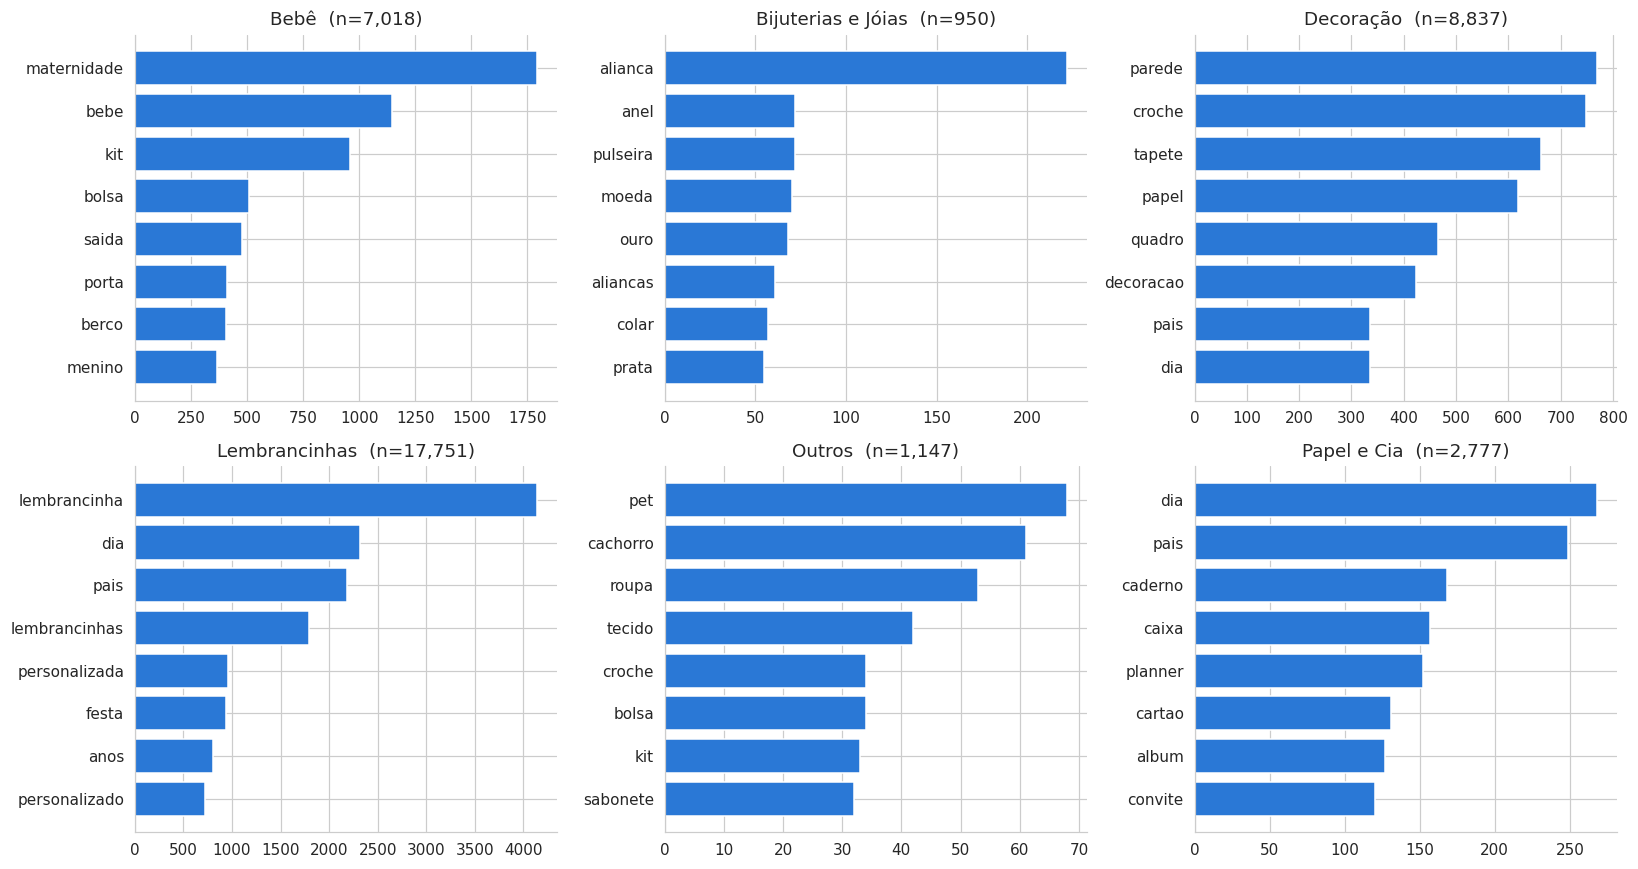

In [74]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

for ax, (cat, sub) in zip(axs.flat, df.groupby("category")):
    tokens = [t for q in sub["query"] for t in tokenize(q, drop_stopwords=True)]
    top = Counter(tokens).most_common(8)
    words, freqs = zip(*top)
    ax.barh(words[::-1], freqs[::-1], color=PRIMARY)
    ax.set_title(f"{cat}  (n={len(sub):,})")

fig.tight_layout()
plt.show()

The vocabularies are clearly distinct: `Bijuterias e Jóias` queries lead with `alianca`
("wedding ring"), `anel`, `pulseira`, `ouro`, `prata`, jewelry-specific words that essentially
never show up elsewhere. `Decoração` leads with `parede` ("wall"), `croche`, `tapete`, `quadro`,
home-decor words. `Bebê` leads with `maternidade`, `berco` ("crib"), `menino`. Even the two most
overlapping categories, `Lembrancinhas` and `Papel e Cia`, share `dia`/`pais` (from "dia dos
pais," Father's Day, a huge seasonal driver in this dataset) but diverge on their next-most-common
words (`caderno`, `planner`, `convite` for `Papel e Cia` vs. `personalizada`, `festa`, `anos` for
`Lembrancinhas`).

This is early, informal evidence (nothing here is a model), but it's a genuinely encouraging
sign for the project's premise: category does look recoverable from query text alone, at least
in aggregate. That's exactly the kind of finding the challenge spec means when it says EDA
insights "will likely inspire ideas" for the next stage.

### Vocabulary overlap between query and product text

A different angle on the same question: how much of the *query* vocabulary also shows up in
`title` or `concatenated_tags`? High overlap would mean queries and product text share a
vocabulary (good news for a query → category classifier that has to work with text alone, per
Part 5 of the challenge, since it means query text isn't some alien vocabulary the product-text
classifier never saw).

In [75]:
query_vocab = {t for q in df["query"] for t in tokenize(q, drop_stopwords=True)}
title_vocab = {t for t_ in df["title"] for t in tokenize(t_, drop_stopwords=True)}
tags_vocab = {t for tg in df["concatenated_tags"] for t in tokenize(tg, drop_stopwords=True)}

product_vocab = title_vocab | tags_vocab
overlap = len(query_vocab & product_vocab)

print(f"query vocabulary   : {len(query_vocab):,} distinct words")
print(f"product vocabulary : {len(product_vocab):,} distinct words (title + tags)")
print(f"overlap            : {overlap:,} ({100 * overlap / len(query_vocab):.1f}% of query vocabulary)")

query vocabulary   : 2,447 distinct words
product vocabulary : 11,145 distinct words (title + tags)
overlap            : 2,310 (94.4% of query vocabulary)


94% of the words people search with also appear somewhere in product titles or tags. That's a
high floor of shared vocabulary to build on. It's not row-level evidence though: it only says
the *vocabularies* overlap globally, not that any given query's words appear in the title of the
specific product that was clicked. That's the next, stricter check.

In [76]:
def query_title_token_overlap(query, title):
    q_tokens = set(tokenize(query, drop_stopwords=True))
    if not q_tokens:
        return np.nan
    t_tokens = set(tokenize(title, drop_stopwords=True))
    return len(q_tokens & t_tokens) / len(q_tokens)


overlap_ratio = df.apply(lambda r: query_title_token_overlap(r["query"], r["title"]), axis=1)

print(f"mean share of query words also in the clicked title  : {overlap_ratio.mean():.2f}")
print(f"median share                                          : {overlap_ratio.median():.2f}")
print(f"rows with zero overlap                                 : {100 * (overlap_ratio == 0).mean():.1f}%")

mean share of query words also in the clicked title  : 0.75
median share                                          : 1.00
rows with zero overlap                                 : 9.0%


At the row level, the median overlap is a full 1.0: for at least half of all clicks, *every*
content word in the query also appears in the title of the product that got clicked. That's
consistent with a lot of search traffic being specific ("I know what I want and I typed it"). But
9% of rows have *zero* word overlap between query and title: clicks where the query text and the
product's own title share no words at all. That gap is a preview of a real distinction worth
carrying into notebook 03: some searches look like specific, targeted lookups, and others look
like something closer to browsing or a near-miss, which is exactly the kind of two-class split
the challenge spec itself suggests as a starting point for intent classes.

## 8. Consolidated feature correlation

Finally, one correlation matrix over every numeric feature built in this notebook (original and
engineered), to see which ones move together. Correlation ranges from -1 to 1 with a meaningful
zero midpoint, so this uses a diverging colormap (blue/red around a white center) rather than the
single-hue sequential map used for magnitude charts earlier; a sequential map would make a
strong negative correlation look identical to no correlation at all.

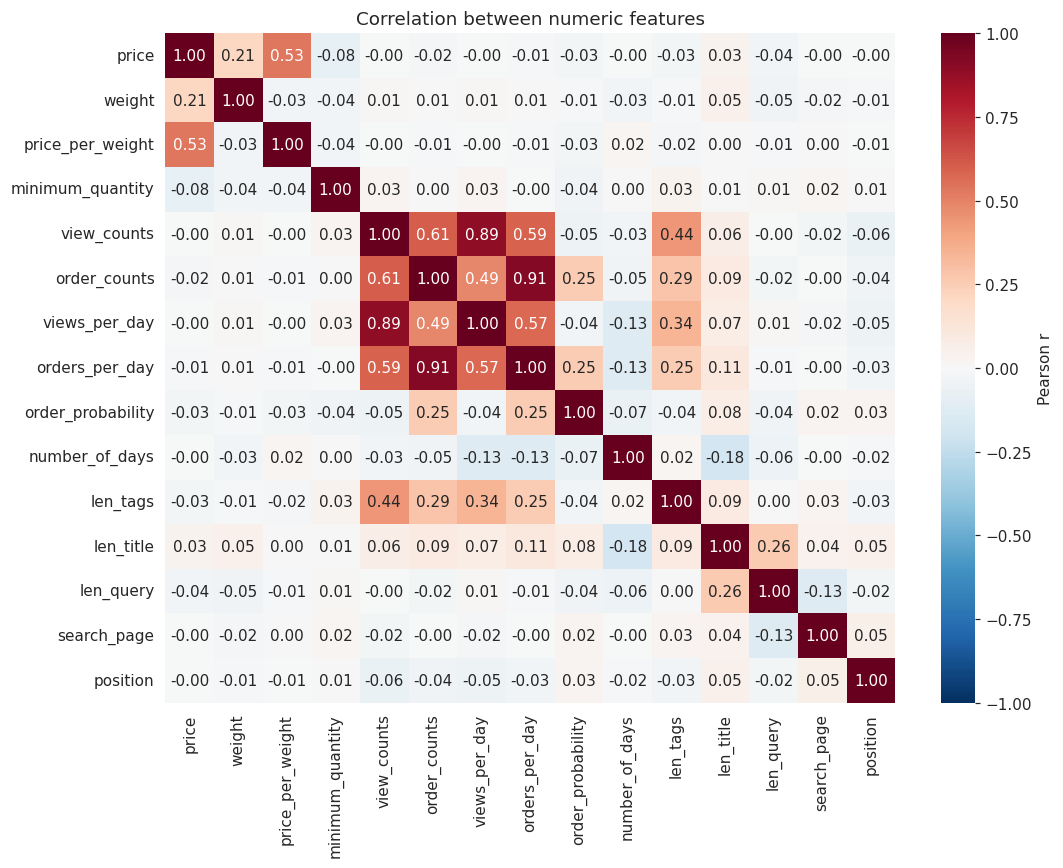

In [77]:
df["number_of_days"] = days_since(df["creation_date"], df["creation_date"].max())
df["views_per_day"] = rate_per_day(df["view_counts"], df["number_of_days"])
df["orders_per_day"] = rate_per_day(df["order_counts"], df["number_of_days"])

numeric_cols = [
    "price", "weight", "price_per_weight", "minimum_quantity",
    "view_counts", "order_counts", "views_per_day", "orders_per_day", "order_probability",
    "number_of_days", "len_tags", "len_title", "len_query", "search_page", "position",
]

corr = df[numeric_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("Correlation between numeric features")
fig.tight_layout()
plt.show()

`days_since` uses the maximum `creation_date` observed in the dataset as its reference point
(rather than "today," which the 2021 version of this analysis used and which made the feature,
and everything derived from it, change value on every run). One product happens to share that
exact reference date, giving it `number_of_days == 0`; `rate_per_day` handles that with the same
`+1` shift `price_per_weight` already uses for `weight == 0`, for the same reason.

Reading the heatmap: the strongest relationships are all internally consistent rather than
surprising: `view_counts`/`views_per_day` (r ≈ 0.89) and `order_counts`/`orders_per_day`
(r ≈ 0.91) are near-restatements of each other by construction, and `price`/`price_per_weight`
(r ≈ 0.53) similarly share `price` as an input. The more informative relationships are the ones
between *independent* pairs: `view_counts` and `order_counts` (r ≈ 0.61) confirm that more-viewed
products do generally sell more, and `len_tags` correlates moderately with both `view_counts`
(r ≈ 0.44) and `order_counts` (r ≈ 0.29): sellers who write more tags tend to get more
engagement, though this is a correlation, not a causal claim (better sellers may simply do both
things well). `number_of_days` stands out for correlating with almost nothing: how long a
product has existed on the platform doesn't predict how much it's viewed or ordered in this
sample.

None of the text-length features (`len_tags`, `len_title`, `len_query`) correlate strongly with
each other or with `price`/`weight`, which is a good sign for Part 2: it means they're likely to
carry information the numeric product features don't already capture, rather than being
redundant with them.

## 9. Key findings & handoff

**Data quality decisions made in this notebook:**

- `order_counts` nulls → filled with `0` (justified, not assumed: every non-null value is ≥ 1,
  so a null almost certainly means "zero orders in the window").
- `concatenated_tags` nulls (2 rows) → filled with `''`.
- `weight` nulls (58 rows) → **kept**, flagged via `weight_missing`, left as `NaN` rather than
  imputed. `price_per_weight` propagates `NaN` for these rows automatically.
- 27 rows with `order_probability > 1` → dropped, after confirming the anomaly isn't
  concentrated in any category or price range.

**What we learned:**

- A row is a click, not a product (29,801 products, 38,507 rows), which changes how every
  "distribution by category" chart should be read, and is a data-leakage risk for a naive
  row-level train/test split in Part 2.
- `category` is imbalanced roughly 18:1 (`Lembrancinhas` vs. `Bijuterias e Jóias`) at both the row
  and product level; Part 2's evaluation needs a metric that isn't fooled by this.
- `price`, `weight`, and `view_counts` are all heavily right-skewed (skewness 15–17): log scale
  for visualization, and something to be aware of for any model sensitive to outliers.
- The character-count variant of a text-length feature (`len_*`) captures meaningfully more
  distinct values than the word-count variant, for every text field: `len_tags`, `len_title`,
  and `len_query` are the ones carried forward.
- **Query text shows real, visible signal for `category`**, even from simple word frequencies:
  distinct vocabularies per category, 94% query/product vocabulary overlap, and a median
  row-level query-title token overlap of 1.0. This is direct, if informal, support for the
  project's core premise.
- A meaningful minority of clicks (9%) show *zero* word overlap between query and the clicked
  title, a hint that at least two different kinds of search behavior are mixed together in this
  data, which lines up with the "specific vs. exploratory" intent split the challenge spec
  suggests as a starting point for notebook 03.

**Saved for the next notebook**, per the persistence convention used in this project's earlier
Kaggle notebooks:

In [78]:
feature_catalog = [
    ("product_id", "categorical", "original", "product_id", "Product identifier. Not unique per row."),
    ("seller_id", "categorical", "original", "seller_id", "Seller identifier."),
    ("query", "text", "original", "query", "Raw search query text."),
    ("search_page", "numerical", "original", "search_page", "Search results page (1-5)."),
    ("position", "numerical", "original", "position", "Position within the results page (0-38)."),
    ("title", "text", "original", "title", "Seller-provided product title."),
    ("concatenated_tags", "text", "original", "concatenated_tags", "Seller-provided tags, space-separated. Nulls filled with ''."),
    ("creation_date", "datetime", "original", "creation_date", "Product creation timestamp."),
    ("price", "numerical", "original", "price", "Product price, BRL."),
    ("weight", "numerical", "original", "weight", "Product weight, grams. NaN kept for missing (see weight_missing)."),
    ("express_delivery", "categorical", "original", "express_delivery", "0/1 flag."),
    ("minimum_quantity", "numerical", "original", "minimum_quantity", "Minimum purchase quantity."),
    ("view_counts", "numerical", "original", "view_counts", "Views in the prior 3 months."),
    ("order_counts", "numerical", "original", "order_counts", "Orders in the prior 3 months. Nulls filled with 0."),
    ("category", "categorical", "original", "category", "Target label for Part 2."),
    ("weight_missing", "categorical", "engineered", "weight", "True where weight is NaN."),
    ("order_probability", "numerical", "engineered", "order_counts, view_counts", "order_counts / view_counts. Rows > 1 dropped."),
    ("price_per_weight", "numerical", "engineered", "price, weight", "price / (weight + 1). NaN where weight is missing."),
    ("number_of_days", "numerical", "engineered", "creation_date", "Days since max(creation_date) in the dataset."),
    ("views_per_day", "numerical", "engineered", "view_counts, number_of_days", "view_counts / (number_of_days + 1)."),
    ("orders_per_day", "numerical", "engineered", "order_counts, number_of_days", "order_counts / (number_of_days + 1)."),
    ("len_tags", "numerical", "engineered", "concatenated_tags", "Character length of cleaned tags. Preferred over word count (more distinct values)."),
    ("len_title", "numerical", "engineered", "title", "Character length of cleaned title."),
    ("len_query", "numerical", "engineered", "query", "Character length of cleaned query."),
]

df_features = pd.DataFrame(feature_catalog, columns=["Name", "Type", "Category", "Source", "Description"])

df.to_parquet("../data/processed/01_data.parquet", index=False)
df_features.to_parquet("../data/processed/01_features.parquet", index=False)

print(f"saved {len(df):,} rows x {df.shape[1]} columns -> data/processed/01_data.parquet")
print(f"saved {len(df_features)} feature rows -> data/processed/01_features.parquet")

saved 38,480 rows x 24 columns -> data/processed/01_data.parquet
saved 24 feature rows -> data/processed/01_features.parquet


## Closing remarks

This notebook cleaned the raw dataset (three different missing-value strategies, one anomaly
removal), built and justified a small set of engineered features (`weight_missing`,
`order_probability`, `price_per_weight`, `number_of_days`, `views_per_day`, `orders_per_day`,
`len_tags`, `len_title`, `len_query`), and, most importantly for this project's actual
question, found early, concrete evidence that a product's `category` leaves a visible fingerprint
on the *search query* that leads to it, not just on the product's own text.

The cleaned dataset and a machine-readable feature catalog are saved to `data/processed/` for
reuse. The [next notebook](02_product_classification.ipynb) builds the supervised classifier for
Part 2, using both the numeric and text features characterized here.